In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Ionian'
NUTS2_ID = 'EL62'
NUTS1_COLNAME = 'NUTS1_ID'
NUTS2_COLNAME = 'NUTS2_ID'

In [4]:
shapefile_gdf = gpd.read_file(f"../../Europe Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

In [5]:
shapefile_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
print(f'shapefile\'s CRS before conversion: {shapefile_gdf.crs}')
shapefile_gdf = shapefile_gdf.to_crs(epsg=4326)
print(f'shapefile\'s CRS after conversion: {shapefile_gdf.crs}')

shapefile's CRS before conversion: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
shapefile's CRS after conversion: EPSG:4326


In [7]:
shapefile_gdf[NUTS2_COLNAME].unique()

array(['EL30', 'EL41', 'EL42', 'EL43', 'EL51', 'EL52', 'EL53', 'EL54',
       'EL61', 'EL62', 'EL63', 'EL64', 'EL65'], dtype=object)

In [8]:
nuts3_gdf = shapefile_gdf.loc[shapefile_gdf[NUTS2_COLNAME] == f'{NUTS2_ID}'].copy()
nuts3_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
37,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL621,Zakynthos,Ζάκυνθος,2.0,3,1,"MULTIPOLYGON (((21.02100 37.24841, 21.02209 37..."
38,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL622,Kerkyra,Κέρκυρα,4.0,3,1,"MULTIPOLYGON (((20.23141 39.15718, 20.23238 39..."
39,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL623,"Ithaki, Kefallinia","Ιθάκη, Κεφαλληνία",3.0,3,1,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
40,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL624,Lefkada,Λευκάδα,3.0,3,1,"MULTIPOLYGON (((20.95923 38.64974, 20.96032 38..."


<Axes: >

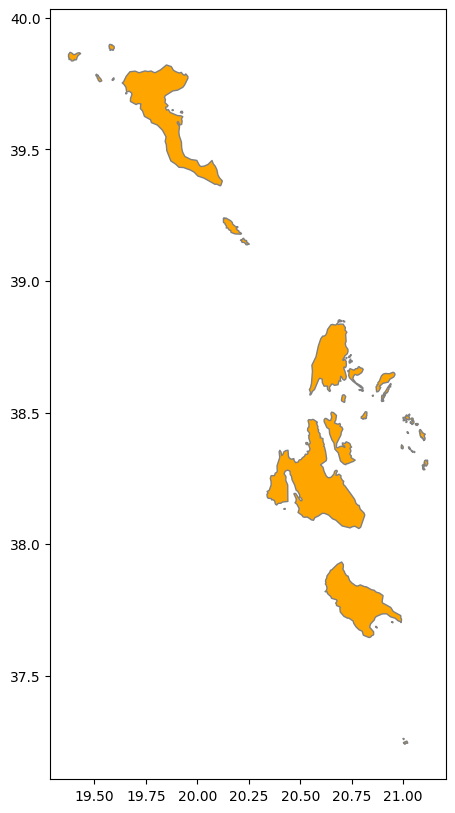

In [9]:
nuts3_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [10]:
nuts2_gdf = nuts3_gdf.dissolve(by = NUTS1_COLNAME, as_index = False)

<Axes: >

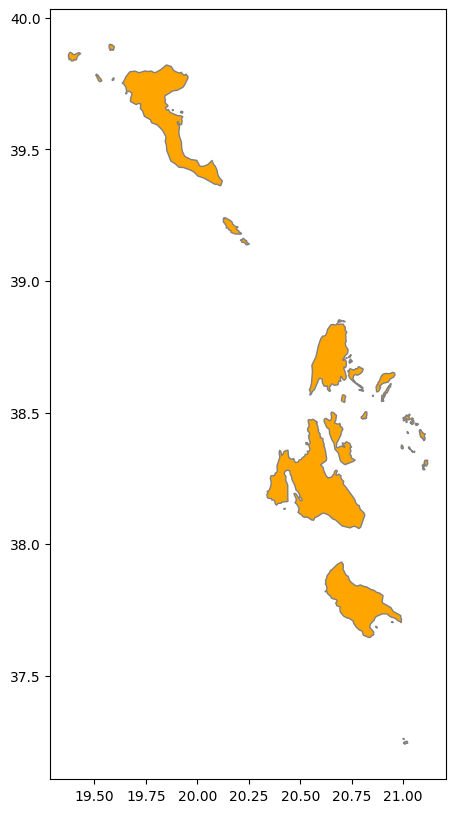

In [11]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [12]:
nuts2_gdf = nuts2_gdf[['NUTS2_ID', 'NUTS2_NAME', 'geometry']]
nuts2_gdf.reset_index(inplace=True, drop = True)

In [13]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal=NUTS2_COLNAME, dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [14]:
df_grid.shape

(366, 5)

In [15]:
df_grid.head()

,geometry,centers,NUTS2_ID,x,y
0,"POLYGON ((19.68962 39.73731, 19.68962 39.75528...",POINT (19.67833104252285 39.74629447822996),EL62,19.67833,39.74629
1,"POLYGON ((19.68962 39.75528, 19.68962 39.77324...",POINT (19.67833104252285 39.76426116983018),EL62,19.67833,39.76426
2,"POLYGON ((19.71218 39.68341, 19.71218 39.70138...",POINT (19.700899193820838 39.692394403429326),EL62,19.70090,39.69239
3,"POLYGON ((19.71218 39.70138, 19.71218 39.71934...",POINT (19.700899193820838 39.71036109502955),EL62,19.70090,39.71036
4,"POLYGON ((19.71218 39.71934, 19.71218 39.73731...",POINT (19.700899193820838 39.72832778662975),EL62,19.70090,39.72833


<Axes: >

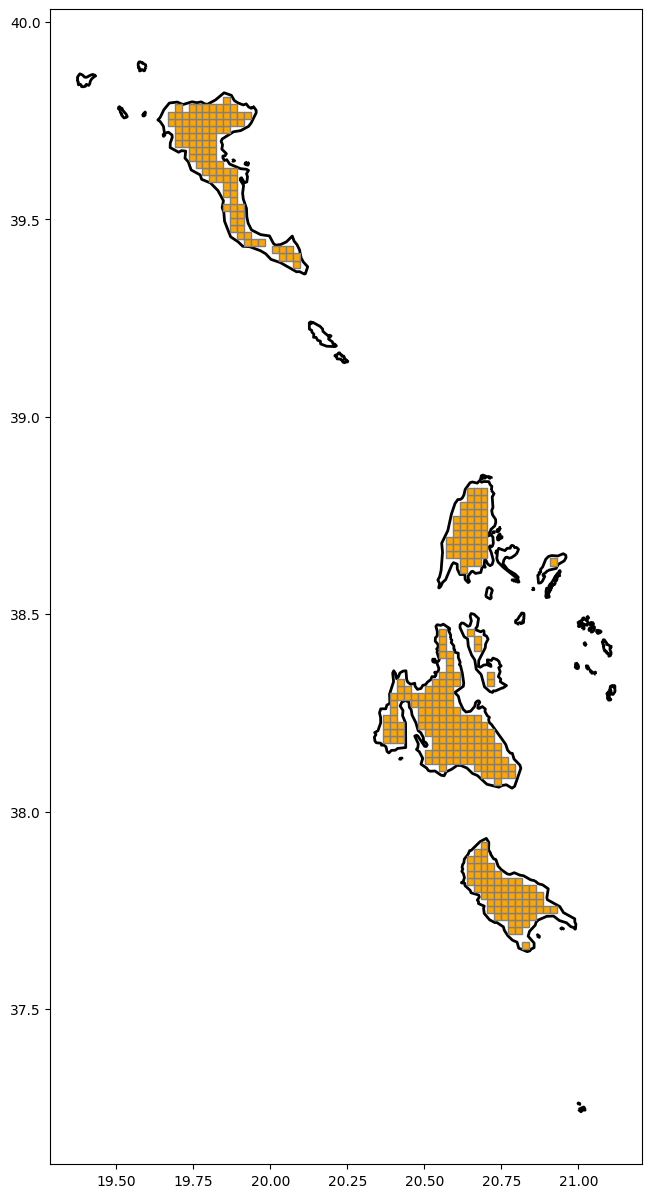

In [16]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [17]:
df_grid.set_geometry('centers', inplace=True)

In [18]:
gdf_merged = gpd.sjoin(df_grid, nuts3_gdf, how='left', op='within')
gdf_merged.set_geometry('geometry', inplace=True)

<Axes: >

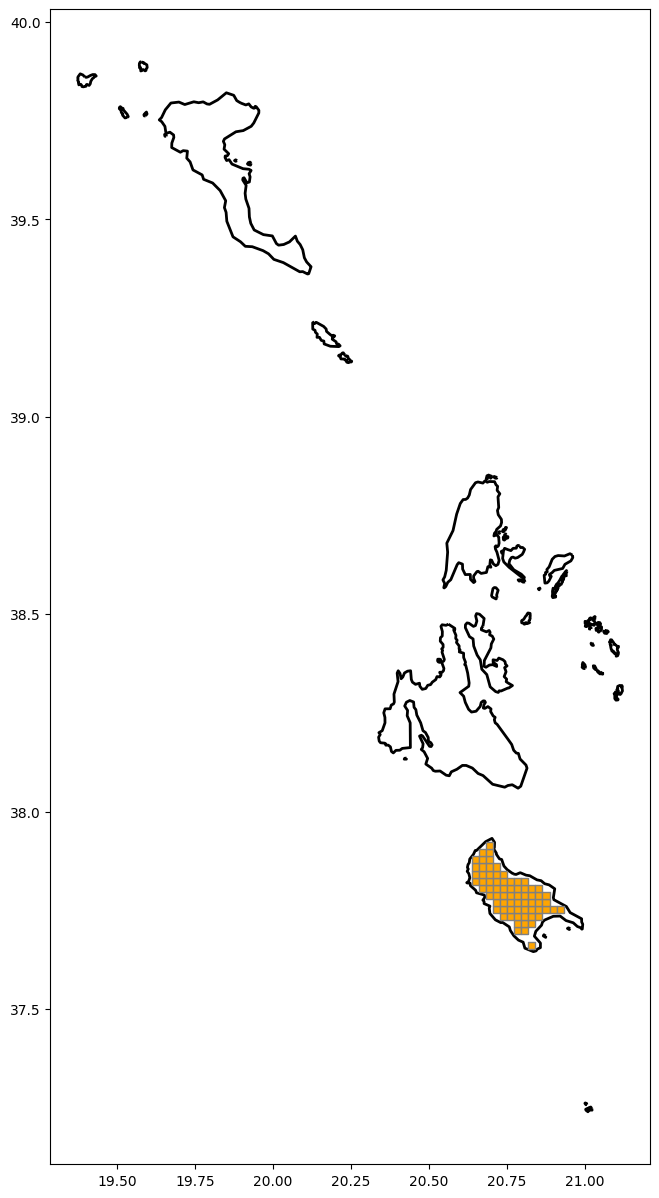

In [19]:
ax = nuts3_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
gdf_merged[gdf_merged['NUTS3_ID'] == 'EL621'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [20]:
gdf_merged.head()

,geometry,centers,NUTS2_ID_left,x,y,index_right,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID_right,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,"POLYGON ((19.68962 39.73731, 19.68962 39.75528...",POINT (19.67833 39.74629),EL62,19.67833,39.74629,38,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL622,Kerkyra,Κέρκυρα,4.0,3,1
1,"POLYGON ((19.68962 39.75528, 19.68962 39.77324...",POINT (19.67833 39.76426),EL62,19.67833,39.76426,38,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL622,Kerkyra,Κέρκυρα,4.0,3,1
2,"POLYGON ((19.71218 39.68341, 19.71218 39.70138...",POINT (19.70090 39.69239),EL62,19.70090,39.69239,38,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL622,Kerkyra,Κέρκυρα,4.0,3,1
3,"POLYGON ((19.71218 39.70138, 19.71218 39.71934...",POINT (19.70090 39.71036),EL62,19.70090,39.71036,38,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL622,Kerkyra,Κέρκυρα,4.0,3,1
4,"POLYGON ((19.71218 39.71934, 19.71218 39.73731...",POINT (19.70090 39.72833),EL62,19.70090,39.72833,38,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL62,Ionia Nisia,Ιόνια Νησιά,EL622,Kerkyra,Κέρκυρα,4.0,3,1


In [21]:
final_grid = gdf_merged[['NUTS2_ID_left', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'geometry']]
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'NUTS2_ID_left': "NUTS2_ID"}, inplace=True)
final_grid.sort_values(by=['NUTS3_ID', 'x', 'y'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

In [22]:
final_grid['cell_code'] = final_grid['NUTS3_ID'] + pd.Series(final_grid.index + 1).apply(lambda x: f"{x:06d}")
process_greek(final_grid, 'NUTS3_NAME')
process_greek(final_grid, 'NUTS2_NAME')

In [23]:
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'cell_code', 'geometry']]

In [24]:
final_grid.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,geometry
0,EL62,ιονια νησια,EL621,ζακυνθος,20.64876,37.82386,EL621000001,"POLYGON ((20.66005 37.81488, 20.66005 37.83284..."
1,EL62,ιονια νησια,EL621,ζακυνθος,20.64876,37.84183,EL621000002,"POLYGON ((20.66005 37.83284, 20.66005 37.85081..."
2,EL62,ιονια νησια,EL621,ζακυνθος,20.64876,37.85979,EL621000003,"POLYGON ((20.66005 37.85081, 20.66005 37.86878..."
3,EL62,ιονια νησια,EL621,ζακυνθος,20.64876,37.87776,EL621000004,"POLYGON ((20.66005 37.86878, 20.66005 37.88674..."
4,EL62,ιονια νησια,EL621,ζακυνθος,20.67133,37.80589,EL621000005,"POLYGON ((20.68261 37.79691, 20.68261 37.81488..."


In [25]:
final_grid.drop(columns='geometry').to_csv(f'../data/GR_{NUTS2}_Grid.csv', encoding=enc, index = False)
final_grid.to_file(f'../data/GR_{NUTS2}_Grid.shp', encoding = 'utf-8')